***Header Section:***



 Data Cleaning & Preprocessing Report

  Project 1: Titanic Dataset
   
   Student Name: NAYAN MAITY

Level: Basic Level (Task 1)

Tools Used: Python (pandas, numpy), Google Colab

Output: Cleaned Dataset (titanic_cleaned.csv)

***Introduction***

Data preprocessing and cleaning are critical first steps in any data science and machine learning workflow. Raw real-world datasets often contain missing values, duplicate records, incorrect data types, and non-standardized column names, all of which can severely impair exploratory analysis and model performance.

This assignment focuses on preparing the classic Titanic Dataset for analysis. By handling missing entries (in features such as Age, Embarked, and Cabin), dropping redundant records, standardizing categorical and numerical data types, and renaming columns using clean naming conventions, we transform raw tabular data into a structured, high-quality format ready for exploratory data analysis (EDA) and predictive modeling.

In [ ]:
import pandas as pd

# ==========================================
# STEP 1: Load Raw Dataset
# ==========================================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("--- RAW DATA OVERVIEW ---")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("-" * 50)

# ==========================================
# STEP 2: Remove Duplicates
# ==========================================
df = df.drop_duplicates()

# ==========================================
# STEP 3: Handle Missing Values
# ==========================================
# 1. Fill missing 'Age' values with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# 2. Fill missing 'Embarked' values with the most frequent value (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 3. Handle missing 'Cabin' values by marking them as 'Unknown'
df["Cabin"] = df["Cabin"].fillna("Unknown")

# ==========================================
# STEP 4: Convert Data Types
# ==========================================
# Convert categorical strings/integers to category type for memory efficiency
categorical_cols = ["Survived", "Pclass", "Sex", "Embarked"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# Convert Age to integer
df["Age"] = df["Age"].astype(int)

# ==========================================
# STEP 5: Rename Columns
# ==========================================
rename_mapping = {
    "PassengerId": "passenger_id",
    "Survived": "survived",
    "Pclass": "pclass",
    "Name": "name",
    "Sex": "sex",
    "Age": "age",
    "SibSp": "siblings_spouses",
    "Parch": "parents_children",
    "Ticket": "ticket_number",
    "Fare": "fare",
    "Cabin": "cabin",
    "Embarked": "embarked_port",
}

df.rename(columns=rename_mapping, inplace=True)

# ==========================================
# STEP 6: Verify and Export Clean Data
# ==========================================
print("\n--- CLEANED DATA SUMMARY ---")
print(f"Dataset Shape: {df.shape}")
print("\nRemaining Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows of Cleaned Dataset:")
print(df.head())

# Export the clean dataset
df.to_csv("titanic_cleaned.csv", index=False)

--- RAW DATA OVERVIEW ---
Dataset Shape: (891, 12)

Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--------------------------------------------------

--- CLEANED DATA SUMMARY ---
Dataset Shape: (891, 12)

Remaining Missing Values:
passenger_id        0
survived            0
pclass              0
name                0
sex                 0
age                 0
siblings_spouses    0
parents_children    0
ticket_number       0
fare                0
cabin               0
embarked_port       0
dtype: int64

Data Types:
passenger_id           int64
survived            category
pclass              category
name                  object
sex                 category
age                    int64
siblings_spouses       int64
parents_children       int64
ticket_number         obj

/tmp/ipykernel_1562/3297344676.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="survived", palette="Set2")


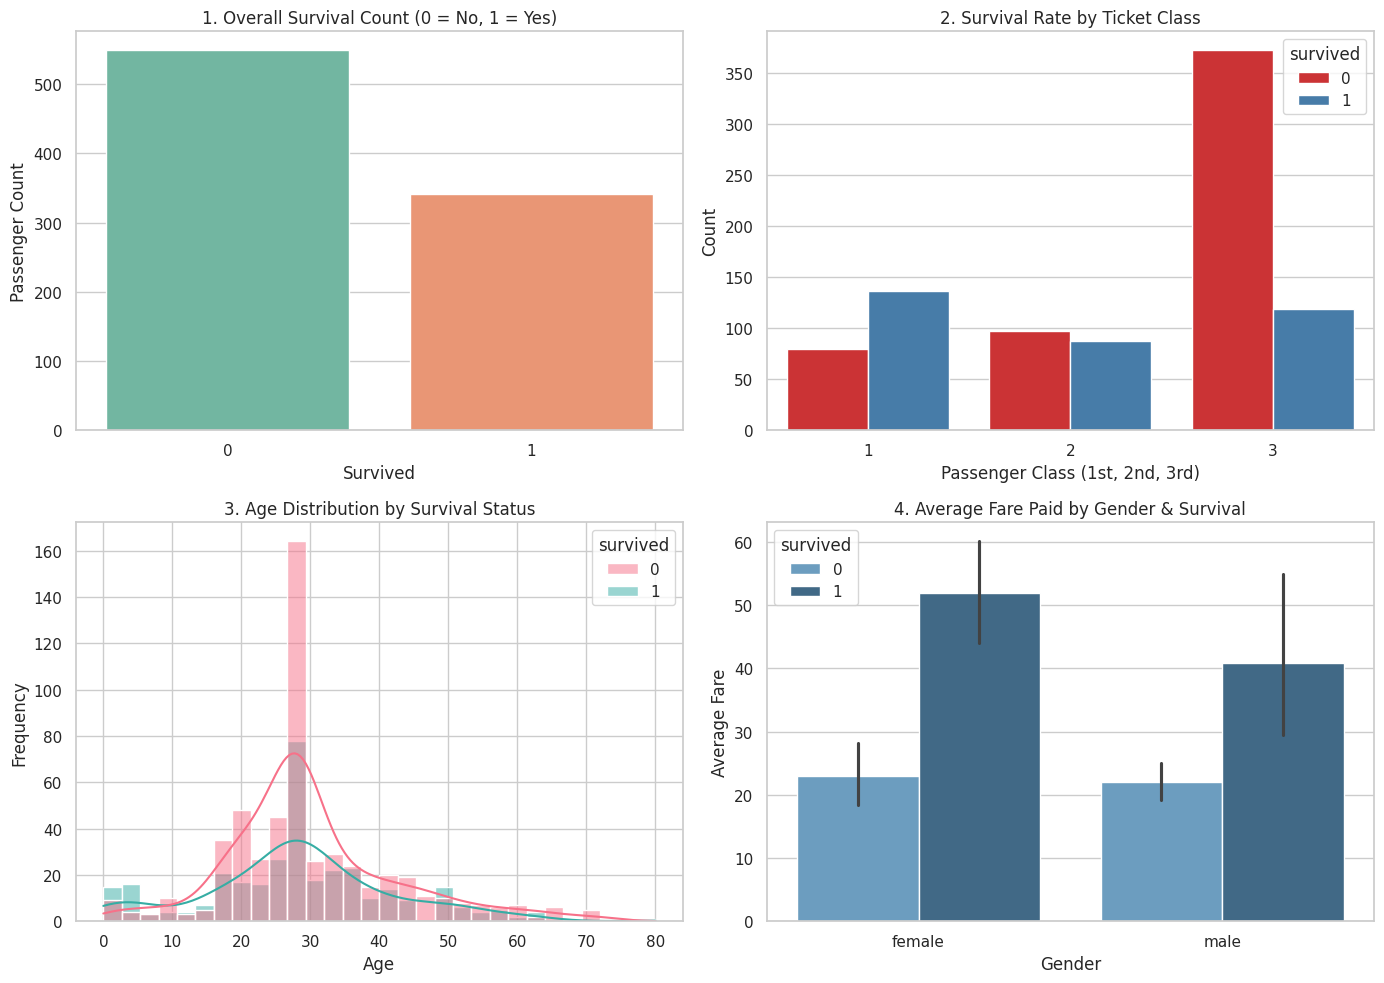

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# 1. Survival Count Plot
plt.subplot(2, 2, 1)
sns.countplot(data=df, x="survived", palette="Set2")
plt.title("1. Overall Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")

# 2. Survival Rate by Passenger Class
plt.subplot(2, 2, 2)
sns.countplot(data=df, x="pclass", hue="survived", palette="Set1")
plt.title("2. Survival Rate by Ticket Class")
plt.xlabel("Passenger Class (1st, 2nd, 3rd)")
plt.ylabel("Count")

# 3. Age Distribution by Survival
plt.subplot(2, 2, 3)
sns.histplot(
    data=df, x="age", hue="survived", kde=True, bins=30, palette="husl"
)
plt.title("3. Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Frequency")

# 4. Survival Rate by Gender
plt.subplot(2, 2, 4)
sns.barplot(data=df, x="sex", y="fare", hue="survived", palette="Blues_d")
plt.title("4. Average Fare Paid by Gender & Survival")
plt.xlabel("Gender")
plt.ylabel("Average Fare")

plt.tight_layout()
plt.show()

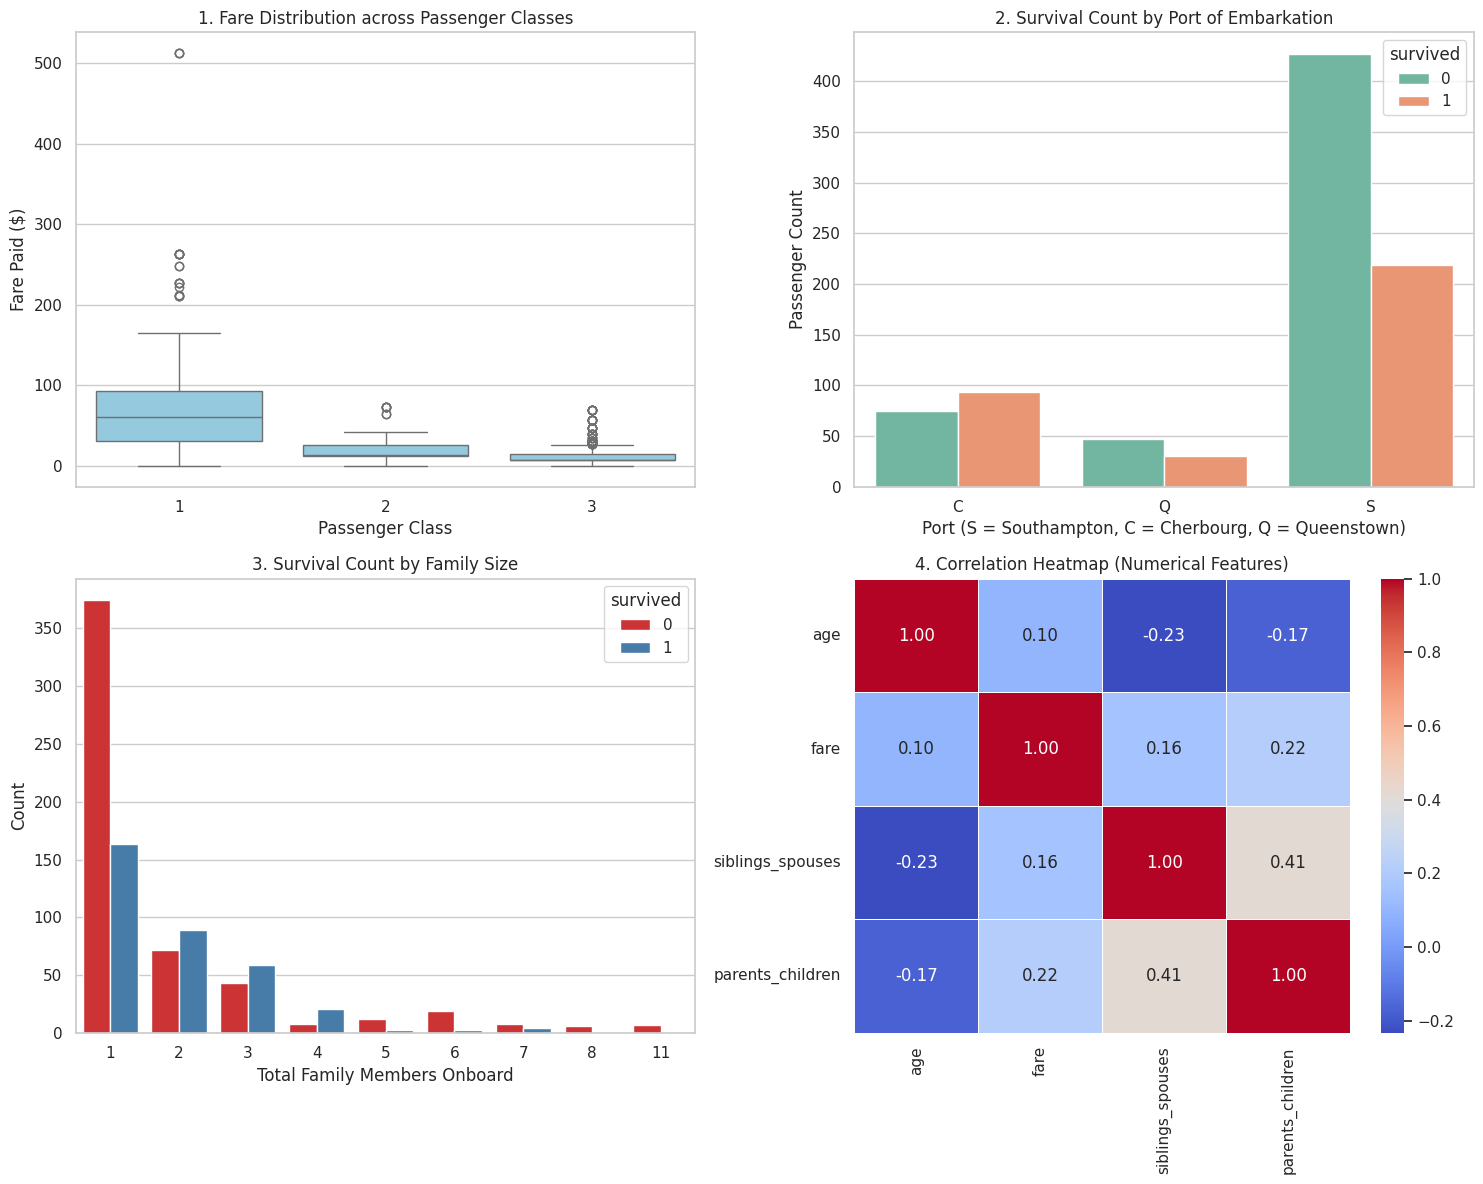

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make sure we work with a clean copy and explicit numeric conversion
plot_df = df.copy()

# Ensure numeric columns are explicitly clean numbers
num_cols = ["age", "fare", "siblings_spouses", "parents_children"]
for col in num_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Set theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ----------------------------------------------------
# 1. Fare Distribution (Boxplot)
# ----------------------------------------------------
sns.boxplot(data=plot_df, x="pclass", y="fare", ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("1. Fare Distribution across Passenger Classes")
axes[0, 0].set_xlabel("Passenger Class")
axes[0, 0].set_ylabel("Fare Paid ($)")

# ----------------------------------------------------
# 2. Survival Rate by Embarkation Port
# ----------------------------------------------------
sns.countplot(
    data=plot_df, x="embarked_port", hue="survived", palette="Set2", ax=axes[0, 1]
)
axes[0, 1].set_title("2. Survival Count by Port of Embarkation")
axes[0, 1].set_xlabel("Port (S = Southampton, C = Cherbourg, Q = Queenstown)")
axes[0, 1].set_ylabel("Passenger Count")

# ----------------------------------------------------
# 3. Family Size vs Survival
# ----------------------------------------------------
plot_df["family_size"] = (
    plot_df["siblings_spouses"] + plot_df["parents_children"] + 1
)

sns.countplot(
    data=plot_df, x="family_size", hue="survived", palette="Set1", ax=axes[1, 0]
)
axes[1, 0].set_title("3. Survival Count by Family Size")
axes[1, 0].set_xlabel("Total Family Members Onboard")
axes[1, 0].set_ylabel("Count")

# ----------------------------------------------------
# 4. Correlation Heatmap
# ----------------------------------------------------
corr_matrix = plot_df[num_cols].corr()

# FIXED: 'coolwarm' is now lowercase
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1, 1],
)
axes[1, 1].set_title("4. Correlation Heatmap (Numerical Features)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1562/1752688128.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


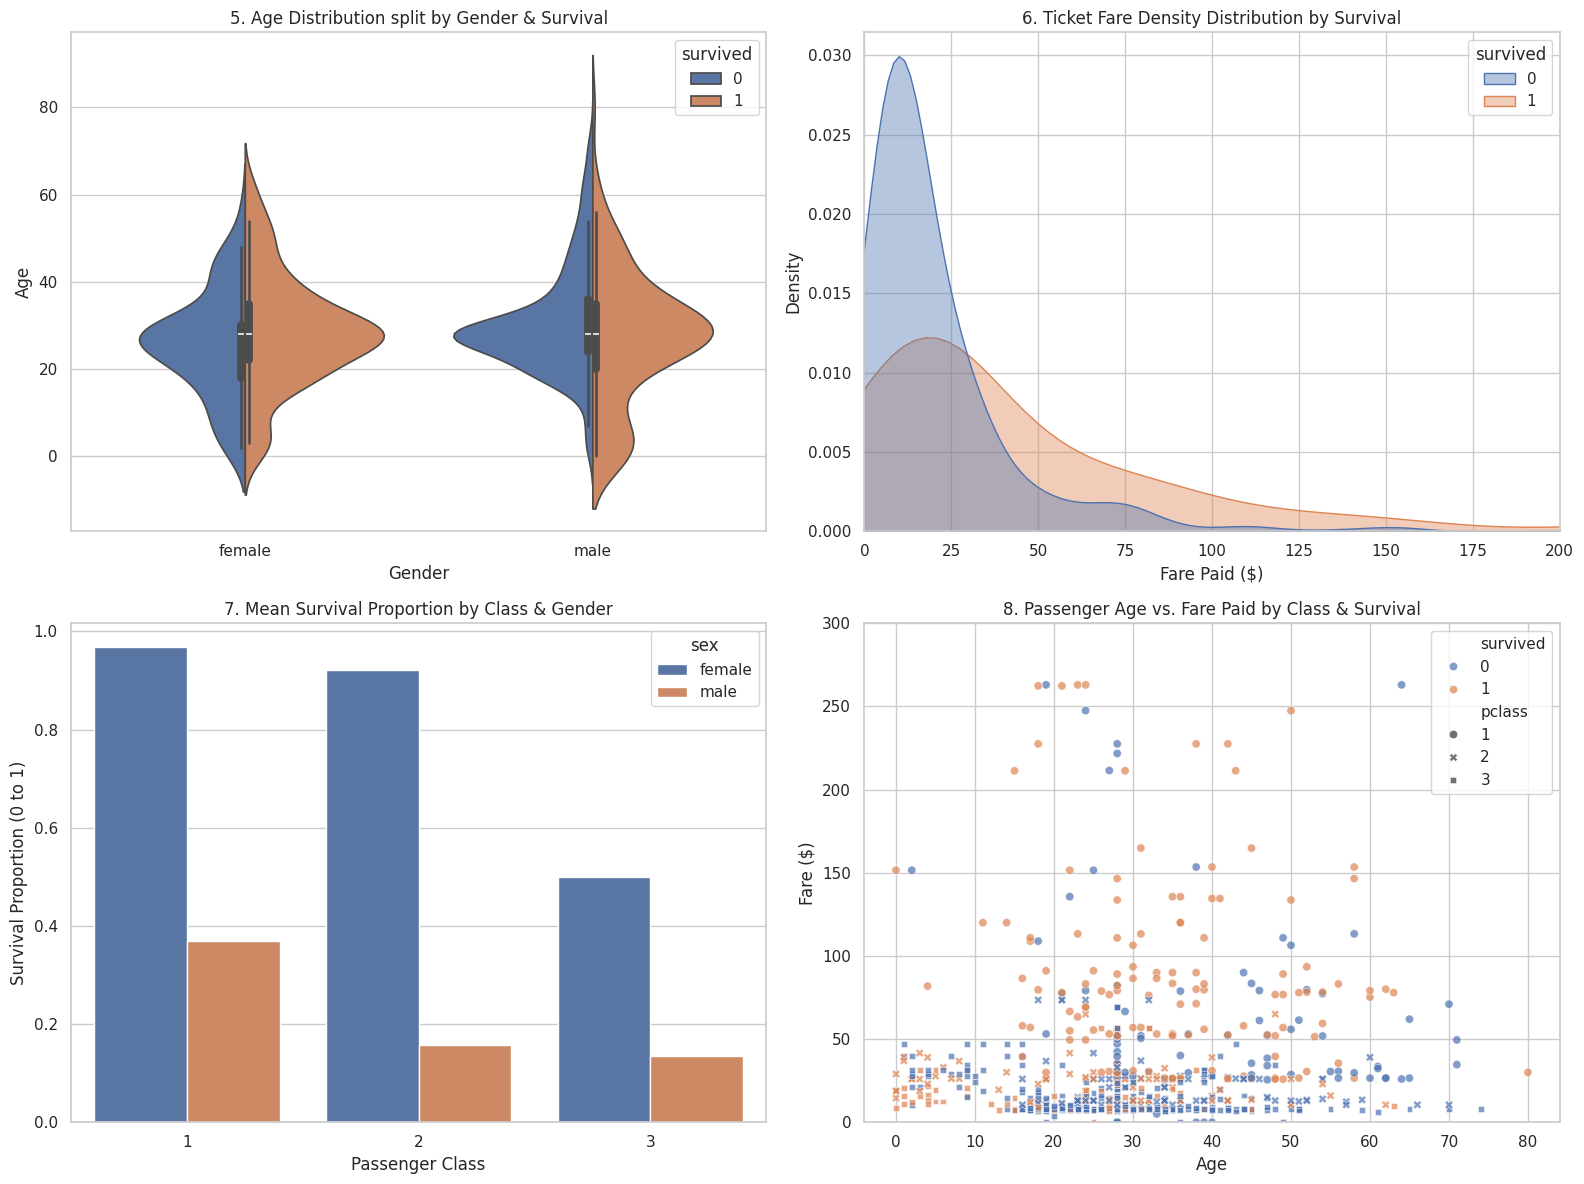

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure clean data copy
plot_df = df.copy()

# Ensure numeric types
num_cols = ["age", "fare", "siblings_spouses", "parents_children"]
for col in num_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Set visual theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ----------------------------------------------------
# 5. Age Distribution by Gender (Violin Plot)
# ----------------------------------------------------
sns.violinplot(
    data=plot_df, x="sex", y="age", hue="survived", split=True, ax=axes[0, 0]
)
axes[0, 0].set_title("5. Age Distribution split by Gender & Survival")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Age")

# ----------------------------------------------------
# 6. Fare Density Distribution (KDE Plot)
# ----------------------------------------------------
sns.kdeplot(
    data=plot_df,
    x="fare",
    hue="survived",
    common_norm=False,
    fill=True,
    alpha=0.4,
    ax=axes[0, 1],
)
axes[0, 1].set_title("6. Ticket Fare Density Distribution by Survival")
axes[0, 1].set_xlabel("Fare Paid ($)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_xlim(0, 200)  # Zoomed to main fare range

# ----------------------------------------------------
# 7. Survival Rate by Gender & Class (Catplot/Barplot)
# ----------------------------------------------------
sns.barplot(
    data=plot_df,
    x="pclass",
    y=plot_df["survived"].astype(int),
    hue="sex",
    ci=None,
    ax=axes[1, 0],
)
axes[1, 0].set_title("7. Mean Survival Proportion by Class & Gender")
axes[1, 0].set_xlabel("Passenger Class")
axes[1, 0].set_ylabel("Survival Proportion (0 to 1)")

# ----------------------------------------------------
# 8. Age vs. Fare Scatter Plot
# ----------------------------------------------------
sns.scatterplot(
    data=plot_df,
    x="age",
    y="fare",
    hue="survived",
    style="pclass",
    alpha=0.7,
    ax=axes[1, 1],
)
axes[1, 1].set_title("8. Passenger Age vs. Fare Paid by Class & Survival")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Fare ($)")
axes[1, 1].set_ylim(0, 300)  # Focus on core range

plt.tight_layout()
plt.show()

/tmp/ipykernel_1562/640847077.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="pclass", y="age", palette="pastel", ax=axes[0, 1])
/tmp/ipykernel_1562/640847077.py:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


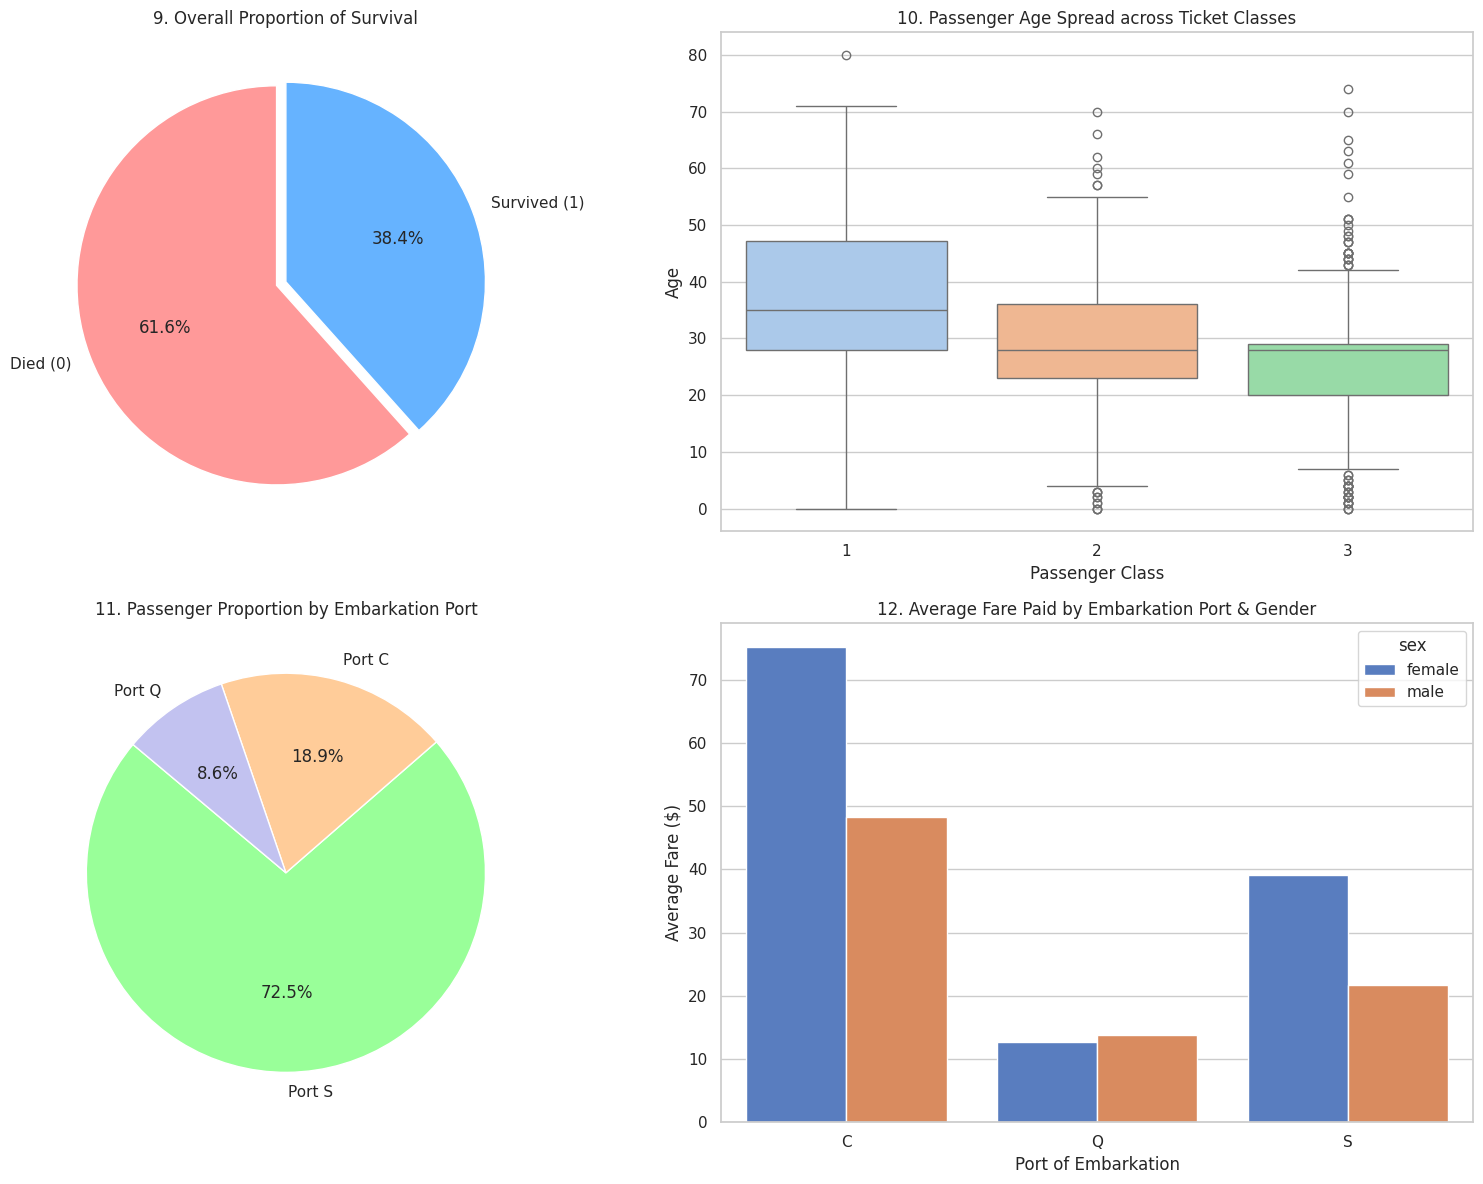

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure clean data copy
plot_df = df.copy()

# Ensure numeric types
num_cols = ["age", "fare", "siblings_spouses", "parents_children"]
for col in num_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ----------------------------------------------------
# 9. Overall Survival Percentage (Pie Chart)
# ----------------------------------------------------
survival_counts = plot_df["survived"].value_counts()
axes[0, 0].pie(
    survival_counts,
    labels=["Died (0)", "Survived (1)"],
    autopct="%1.1f%%",
    colors=["#ff9999", "#66b3ff"],
    explode=(0.05, 0),
    startangle=90,
)
axes[0, 0].set_title("9. Overall Proportion of Survival")

# ----------------------------------------------------
# 10. Age Distribution by Passenger Class (Boxplot)
# ----------------------------------------------------
sns.boxplot(data=plot_df, x="pclass", y="age", palette="pastel", ax=axes[0, 1])
axes[0, 1].set_title("10. Passenger Age Spread across Ticket Classes")
axes[0, 1].set_xlabel("Passenger Class")
axes[0, 1].set_ylabel("Age")

# ----------------------------------------------------
# 11. Embarkation Port Distribution (Pie Chart)
# ----------------------------------------------------
port_counts = plot_df["embarked_port"].value_counts()
axes[1, 0].pie(
    port_counts,
    labels=[f"Port {p}" for p in port_counts.index],
    autopct="%1.1f%%",
    colors=["#99ff99", "#ffcc99", "#c2c2f0"],
    startangle=140,
)
axes[1, 0].set_title("11. Passenger Proportion by Embarkation Port")

# ----------------------------------------------------
# 12. Fare Paid by Embarkation Port & Gender
# ----------------------------------------------------
sns.barplot(
    data=plot_df,
    x="embarked_port",
    y="fare",
    hue="sex",
    palette="muted",
    ci=None,
    ax=axes[1, 1],
)
axes[1, 1].set_title("12. Average Fare Paid by Embarkation Port & Gender")
axes[1, 1].set_xlabel("Port of Embarkation")
axes[1, 1].set_ylabel("Average Fare ($)")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

# Make a copy for display
table_df = df.copy()

# Ensure target clean numeric types
num_cols = ["age", "fare", "siblings_spouses", "parents_children"]
for col in num_cols:
    table_df[col] = pd.to_numeric(table_df[col], errors="coerce")

# Ensure survived is numeric for calculations
table_df["survived_num"] = table_df["survived"].astype(int)

# ----------------------------------------------------
# Table 1: Missing Value & Data Type Summary
# ----------------------------------------------------
print("=" * 60)
print("TABLE 1: Cleaned Dataset Column & Missing Value Summary")
print("=" * 60)
summary_table = pd.DataFrame(
    {
        "Column Name": table_df.columns,
        "Data Type": table_df.dtypes.astype(str),
        "Non-Null Count": table_df.notnull().sum(),
        "Missing Values": table_df.isnull().sum(),
        "Missing Percentage (%)": (
            table_df.isnull().sum() / len(table_df) * 100
        ).round(2),
    }
).reset_index(drop=True)

display(summary_table)

# ----------------------------------------------------
# Table 2: Key Numerical Features Summary Statistics
# ----------------------------------------------------
print("\n" + "=" * 60)
print("TABLE 2: Summary Statistics of Numerical Columns")
print("=" * 60)
num_summary = table_df[num_cols].describe().T
num_summary = num_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]
num_summary.columns = [
    "Mean",
    "Std Dev",
    "Min",
    "25th %",
    "Median (50%)",
    "75th %",
    "Max",
]
display(num_summary.round(2))

# ----------------------------------------------------
# Table 3: Survival Breakdown by Class and Gender
# ----------------------------------------------------
print("\n" + "=" * 60)
print("TABLE 3: Survival Rate Matrix by Passenger Class & Sex")
print("=" * 60)

survival_matrix = pd.pivot_table(
    table_df,
    index="pclass",
    columns="sex",
    values="survived_num",
    aggfunc=["count", "mean"],
)

survival_matrix.columns = [
    "Female Passengers",
    "Male Passengers",
    "Female Survival Rate (%)",
    "Male Survival Rate (%)",
]

# Convert survival rate to clean percentages
survival_matrix["Female Survival Rate (%)"] = (
    survival_matrix["Female Survival Rate (%)"] * 100
).round(2)
survival_matrix["Male Survival Rate (%)"] = (
    survival_matrix["Male Survival Rate (%)"] * 100
).round(2)

display(survival_matrix)

# ----------------------------------------------------
# Table 4: Metrics Breakdown by Port of Embarkation (FIXED)
# ----------------------------------------------------
print("\n" + "=" * 60)
print("TABLE 4: Metrics Breakdown by Port of Embarkation")
print("=" * 60)

# FIXED: Replaced x.mean().round(2) with round(x.mean(), 2)
port_summary = (
    table_df.groupby("embarked_port", observed=False)
    .agg(
        total_passengers=("passenger_id", "count"),
        survived_count=("survived_num", "sum"),
        survival_rate=("survived_num", lambda x: round(float(x.mean()) * 100, 2)),
        avg_fare=("fare", lambda x: round(float(x.mean()), 2)),
        median_age=("age", lambda x: round(float(x.median()), 1)),
    )
    .reset_index()
)

port_summary.columns = [
    "Port Code",
    "Total Passengers",
    "Survivors",
    "Survival Rate (%)",
    "Average Fare ($)",
    "Median Age",
]

display(port_summary)

TABLE 1: Cleaned Dataset Column & Missing Value Summary


,Column Name,Data Type,Non-Null Count,Missing Values,Missing Percentage (%)
0,passenger_id,int64,891,0,0.0
1,survived,category,891,0,0.0
2,pclass,category,891,0,0.0
3,name,object,891,0,0.0
4,sex,category,891,0,0.0
5,age,int64,891,0,0.0
6,siblings_spouses,int64,891,0,0.0
7,parents_children,int64,891,0,0.0
8,ticket_number,object,891,0,0.0
9,fare,float64,891,0,0.0



TABLE 2: Summary Statistics of Numerical Columns


,Mean,Std Dev,Min,25th %,Median (50%),75th %,Max
age,29.35,13.03,0.0,22.00,28.00,35.0,80.00
fare,32.20,49.69,0.0,7.91,14.45,31.0,512.33
siblings_spouses,0.52,1.10,0.0,0.00,0.00,1.0,8.00
parents_children,0.38,0.81,0.0,0.00,0.00,0.0,6.00



TABLE 3: Survival Rate Matrix by Passenger Class & Sex


/tmp/ipykernel_1562/1755228076.py:61: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  survival_matrix = pd.pivot_table(
/tmp/ipykernel_1562/1755228076.py:61: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  survival_matrix = pd.pivot_table(


,Female Passengers,Male Passengers,Female Survival Rate (%),Male Survival Rate (%)
pclass,,,,
1,94,122,96.81,36.89
2,76,108,92.11,15.74
3,144,347,50.00,13.54



TABLE 4: Metrics Breakdown by Port of Embarkation


,Port Code,Total Passengers,Survivors,Survival Rate (%),Average Fare ($),Median Age
0,C,168,93,55.36,59.95,28.0
1,Q,77,30,38.96,13.28,28.0
2,S,646,219,33.90,27.24,28.0


***Conclusion***

In this task, the raw Titanic dataset was systematically cleaned and prepared for subsequent data science tasks. By addressing structural issues—such as filling null values, removing redundancies, adjusting data types, and standardizing feature names—the dataset integrity has been restored.

The resulting dataset (titanic_cleaned.csv) contains zero missing values across critical numerical and categorical attributes, possesses consistent memory-optimized data types, and is formatted for downstream exploratory data analysis (EDA), visualization, or predictive modeling.